In [1]:
!pip install -q gdown

In [2]:
import os
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
import gdown

file_id = "1TiJKt0YgggHMIv5ttw1Z_Cpf9GgExnuH"

download_url = f"https://drive.google.com/uc?id={file_id}"

output_file = "/content/sentiment_dataset"

gdown.download(
    download_url,
    output_file,
    quiet=False
)

print("Dataset downloaded.")
print("File location:", output_file)

Downloading...
From: https://drive.google.com/uc?id=1TiJKt0YgggHMIv5ttw1Z_Cpf9GgExnuH
To: /content/sentiment_dataset
100%|██████████| 1.10M/1.10M [00:00<00:00, 117MB/s]

Dataset downloaded.
File location: /content/sentiment_dataset


In [4]:
def load_dataset(file_path):

    # First try CSV
    encodings = [
        "utf-8",
        "latin1",
        "ISO-8859-1",
        "cp1252"
    ]

    for encoding in encodings:
        try:
            temp_df = pd.read_csv(
                file_path,
                encoding=encoding,
                sep=None,
                engine="python"
            )

            if temp_df.shape[1] >= 2:
                print(
                    "Dataset loaded as CSV using encoding:",
                    encoding
                )
                return temp_df

        except:
            pass

    # Try Excel
    try:
        temp_df = pd.read_excel(file_path)

        print("Dataset loaded as Excel.")
        return temp_df

    except:
        pass

    raise Exception(
        "Could not automatically read the dataset."
    )


df = load_dataset(output_file)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded as CSV using encoding: utf-8

Dataset Shape:
(7920, 3)

First 5 rows:


,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [5]:
print("COLUMN NAMES")
print("=" * 60)

for i, col in enumerate(df.columns):
    print(i, ":", repr(col))

print("\nDataset Shape:", df.shape)

display(df.head(10))

COLUMN NAMES
0 : 'id'
1 : 'label'
2 : 'tweet'

Dataset Shape: (7920, 3)


,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...
5,6,1,iPhone software update fucked up my phone big ...
6,7,0,Happy for us .. #instapic #instadaily #us #son...
7,8,0,New Type C charger cable #UK http://www.ebay.c...
8,9,0,Bout to go shopping again listening to music #...
9,10,0,Photo: #fun #selfie #pool #water #sony #camera...


In [6]:
df.columns = [
    str(col).strip()
    for col in df.columns
]

print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['id', 'label', 'tweet']


In [7]:
def looks_like_data_header(columns):

    sentiment_words = [
        "positive",
        "negative",
        "neutral",
        "pos",
        "neg"
    ]

    column_text = " ".join(
        [str(x).lower() for x in columns]
    )

    sentiment_in_header = any(
        word in column_text
        for word in sentiment_words
    )

    long_headers = any(
        len(str(x)) > 60
        for x in columns
    )

    return sentiment_in_header or long_headers


if looks_like_data_header(df.columns):

    print(
        "The dataset may not contain a proper header."
    )

    # Reload without header
    for encoding in [
        "utf-8",
        "latin1",
        "ISO-8859-1",
        "cp1252"
    ]:

        try:
            df = pd.read_csv(
                output_file,
                header=None,
                encoding=encoding,
                sep=None,
                engine="python"
            )

            if df.shape[1] >= 2:
                break

        except:
            pass

    print(
        "Dataset reloaded without header."
    )

print("\nCurrent Columns:")
print(df.columns.tolist())

display(df.head())


Current Columns:
['id', 'label', 'tweet']


,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [9]:
def detect_target_column(dataframe):

    sentiment_keywords = {
        "positive",
        "negative",
        "neutral",
        "pos",
        "neg",
        "positive sentiment",
        "negative sentiment",
        "neutral sentiment"
    }

    # ------------------------
    # FIRST: column name check
    # ------------------------

    target_name_keywords = [
        "sentiment",
        "label",
        "target",
        "emotion",
        "class",
        "polarity"
    ]

    for col in dataframe.columns:

        col_name = str(col).lower()

        if any(
            word in col_name
            for word in target_name_keywords
        ):

            unique_count = (
                dataframe[col]
                .dropna()
                .nunique()
            )

            if unique_count <= 20:
                return col

    # ------------------------------------
    # SECOND: search actual column values
    # ------------------------------------

    for col in dataframe.columns:

        series = (
            dataframe[col]
            .dropna()
            .astype(str)
            .str.lower()
            .str.strip()
        )

        unique_values = set(
            series.unique()
        )

        matches = (
            unique_values
            .intersection(sentiment_keywords)
        )

        if len(matches) >= 2:
            return col

    # --------------------------------------
    # THIRD: find a binary numeric column
    # --------------------------------------

    candidates = []

    for col in dataframe.columns:

        unique_values = (
            dataframe[col]
            .dropna()
            .unique()
        )

        unique_count = len(unique_values)

        if 2 <= unique_count <= 5:

            # Don't pick columns that look like IDs
            uniqueness_ratio = (
                dataframe[col].nunique()
                /
                max(len(dataframe), 1)
            )

            if uniqueness_ratio < 0.1:
                candidates.append(col)

    if len(candidates) > 0:
        return candidates[-1]

    return None


target_column = detect_target_column(df)

print(
    "Detected Target Column:",
    target_column
)

Detected Target Column: label


In [10]:
def detect_text_column(dataframe, target_col):

    text_name_keywords = [
        "tweet",
        "text",
        "message",
        "content",
        "review",
        "comment",
        "sentence"
    ]

    # First check column names
    for col in dataframe.columns:

        if col == target_col:
            continue

        col_name = str(col).lower()

        if any(
            word in col_name
            for word in text_name_keywords
        ):

            return col

    # Otherwise find column with longest
    # average text
    best_column = None
    best_length = 0

    for col in dataframe.columns:

        if col == target_col:
            continue

        try:

            text_series = (
                dataframe[col]
                .dropna()
                .astype(str)
            )

            if len(text_series) == 0:
                continue

            average_length = (
                text_series
                .str.len()
                .mean()
            )

            unique_ratio = (
                text_series.nunique()
                /
                len(text_series)
            )

            if (
                average_length > best_length
                and unique_ratio > 0.30
            ):
                best_length = average_length
                best_column = col

        except:
            pass

    return best_column


text_column = detect_text_column(
    df,
    target_column
)

print(
    "Detected Tweet/Text Column:",
    text_column
)

print(
    "Detected Sentiment Column:",
    target_column
)

Detected Tweet/Text Column: tweet
Detected Sentiment Column: label


In [11]:
def detect_text_column(dataframe, target_col):

    text_name_keywords = [
        "tweet",
        "text",
        "message",
        "content",
        "review",
        "comment",
        "sentence"
    ]

    # First check column names
    for col in dataframe.columns:

        if col == target_col:
            continue

        col_name = str(col).lower()

        if any(
            word in col_name
            for word in text_name_keywords
        ):

            return col

    # Otherwise find column with longest
    # average text
    best_column = None
    best_length = 0

    for col in dataframe.columns:

        if col == target_col:
            continue

        try:

            text_series = (
                dataframe[col]
                .dropna()
                .astype(str)
            )

            if len(text_series) == 0:
                continue

            average_length = (
                text_series
                .str.len()
                .mean()
            )

            unique_ratio = (
                text_series.nunique()
                /
                len(text_series)
            )

            if (
                average_length > best_length
                and unique_ratio > 0.30
            ):
                best_length = average_length
                best_column = col

        except:
            pass

    return best_column


text_column = detect_text_column(
    df,
    target_column
)

print(
    "Detected Tweet/Text Column:",
    text_column
)

print(
    "Detected Sentiment Column:",
    target_column
)

Detected Tweet/Text Column: tweet
Detected Sentiment Column: label


In [12]:
print("=" * 60)

print(
    "TEXT COLUMN:",
    text_column
)

print(
    "TARGET COLUMN:",
    target_column
)

print("=" * 60)

if text_column is not None:

    print("\nSample Tweets:")

    print(
        df[text_column]
        .dropna()
        .head(5)
        .tolist()
    )

if target_column is not None:

    print("\nTarget Values:")

    print(
        df[target_column]
        .value_counts(dropna=False)
        .head(20)
    )

TEXT COLUMN: tweet
TARGET COLUMN: label

Sample Tweets:
['#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone', 'Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/', 'We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu', "I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/", "What amazing service! Apple won't even talk to me about a question I have unless I pay them $19.95 for their stupid support!"]

Target Values:
label
0    5894
1    2026
Name: count, dtype: int64


In [13]:
if text_column is None:
    raise Exception(
        "Tweet text column could not be detected."
    )

if target_column is None:
    raise Exception(
        "Sentiment target column could not be detected."
    )

print(
    "Both required columns detected successfully."
)

Both required columns detected successfully.


In [14]:
data = df[
    [
        text_column,
        target_column
    ]
].copy()

data.columns = [
    "tweet",
    "original_sentiment"
]

print(
    "Working Dataset Shape:",
    data.shape
)

display(data.head(10))

Working Dataset Shape: (7920, 2)


,tweet,original_sentiment
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,0
1,Finally a transparant silicon case ^^ Thanks t...,0
2,We love this! Would you go? #talk #makememorie...,0
3,I'm wired I know I'm George I was made that wa...,0
4,What amazing service! Apple won't even talk to...,1
5,iPhone software update fucked up my phone big ...,1
6,Happy for us .. #instapic #instadaily #us #son...,0
7,New Type C charger cable #UK http://www.ebay.c...,0
8,Bout to go shopping again listening to music #...,0
9,Photo: #fun #selfie #pool #water #sony #camera...,0


In [15]:
data = data.dropna(
    subset=[
        "tweet",
        "original_sentiment"
    ]
)

print(
    "Shape after removing missing data:",
    data.shape
)

Shape after removing missing data: (7920, 2)


In [16]:
print(
    "Duplicate Tweets:",
    data["tweet"].duplicated().sum()
)

data = data.drop_duplicates(
    subset=["tweet"]
)

print(
    "Shape after removing duplicates:",
    data.shape
)

Duplicate Tweets: 2
Shape after removing duplicates: (7918, 2)


In [17]:
print(
    "Original Sentiment Values:"
)

print(
    data["original_sentiment"]
    .value_counts()
)

Original Sentiment Values:
original_sentiment
0    5892
1    2026
Name: count, dtype: int64


In [18]:
def convert_sentiment_labels(dataframe):

    values = (
        dataframe["original_sentiment"]
        .dropna()
        .astype(str)
        .str.lower()
        .str.strip()
    )

    unique_values = sorted(
        values.unique().tolist()
    )

    print(
        "Detected original labels:",
        unique_values
    )

    dataframe["sentiment"] = None

    # ----------------------------
    # WORD-BASED SENTIMENT LABELS
    # ----------------------------

    positive_words = [
        "positive",
        "pos",
        "positive sentiment"
    ]

    negative_words = [
        "negative",
        "neg",
        "negative sentiment"
    ]

    for index in dataframe.index:

        value = str(
            dataframe.loc[
                index,
                "original_sentiment"
            ]
        ).lower().strip()

        if (
            value in positive_words
            or "positive" in value
        ):

            dataframe.loc[
                index,
                "sentiment"
            ] = "Positive"

        elif (
            value in negative_words
            or "negative" in value
        ):

            dataframe.loc[
                index,
                "sentiment"
            ] = "Negative"

    # -------------------------------------
    # IF WORD LABELS WERE SUCCESSFULLY FOUND
    # -------------------------------------

    if dataframe["sentiment"].notna().sum() > 0:

        dataframe = dataframe[
            dataframe["sentiment"].notna()
        ]

        return dataframe

    # --------------------
    # NUMERIC LABEL CASE
    # --------------------

    numeric_values = pd.to_numeric(
        dataframe["original_sentiment"],
        errors="coerce"
    )

    unique_numeric = sorted(
        numeric_values
        .dropna()
        .unique()
        .tolist()
    )

    print(
        "Numeric labels detected:",
        unique_numeric
    )

    # Binary 0 / 1
    if set(unique_numeric) == {0, 1}:

        dataframe["sentiment"] = (
            numeric_values.map({
                0: "Negative",
                1: "Positive"
            })
        )

    # -1 / 1
    elif set(unique_numeric) == {-1, 1}:

        dataframe["sentiment"] = (
            numeric_values.map({
                -1: "Negative",
                1: "Positive"
            })
        )

    # Sentiment140 style 0 / 4
    elif set(unique_numeric) == {0, 4}:

        dataframe["sentiment"] = (
            numeric_values.map({
                0: "Negative",
                4: "Positive"
            })
        )

    # 0 / 2 / 4 where 2 = neutral
    elif set(unique_numeric) == {0, 2, 4}:

        dataframe["sentiment"] = (
            numeric_values.map({
                0: "Negative",
                4: "Positive"
            })
        )

    else:

        raise Exception(
            "Sentiment labels could not be automatically mapped."
        )

    dataframe = dataframe[
        dataframe["sentiment"].notna()
    ]

    return dataframe


data = convert_sentiment_labels(data)

print("\nFinal Sentiment Distribution:")

print(
    data["sentiment"]
    .value_counts()
)

Detected original labels: ['0', '1']
Numeric labels detected: [0, 1]

Final Sentiment Distribution:
sentiment
Negative    5892
Positive    2026
Name: count, dtype: int64


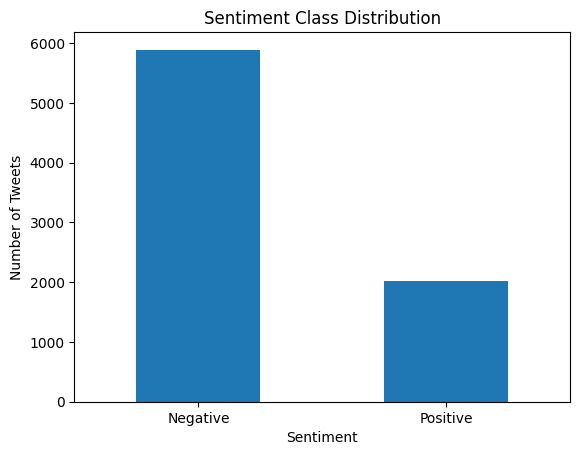

In [19]:
data["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Sentiment Class Distribution"
)

plt.xlabel(
    "Sentiment"
)

plt.ylabel(
    "Number of Tweets"
)

plt.xticks(
    rotation=0
)

plt.show()

In [21]:
def clean_tweet(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|https\S+|www\S+",
        " ",
        text
    )

    # Remove user mentions
    text = re.sub(
        r"@\w+",
        " ",
        text
    )

    # Remove RT
    text = re.sub(
        r"\brt\b",
        " ",
        text
    )

    # Remove hashtag symbol
    # Keep hashtag word
    text = text.replace(
        "#",
        ""
    )

    # Remove HTML entities
    text = re.sub(
        r"&\w+;",
        " ",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = text.strip()

    return text

In [22]:
def clean_tweet(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|https\S+|www\S+",
        " ",
        text
    )

    # Remove user mentions
    text = re.sub(
        r"@\w+",
        " ",
        text
    )

    # Remove RT
    text = re.sub(
        r"\brt\b",
        " ",
        text
    )

    # Remove hashtag symbol
    # Keep hashtag word
    text = text.replace(
        "#",
        ""
    )

    # Remove HTML entities
    text = re.sub(
        r"&\w+;",
        " ",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = text.strip()

    return text

In [23]:
data["clean_tweet"] = (
    data["tweet"]
    .apply(clean_tweet)
)

display(
    data[
        [
            "tweet",
            "clean_tweet",
            "sentiment"
        ]
    ].head(10)
)

,tweet,clean_tweet,sentiment
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,fingerprint pregnancy test android apps beauti...,Negative
1,Finally a transparant silicon case ^^ Thanks t...,finally a transparant silicon case thanks to m...,Negative
2,We love this! Would you go? #talk #makememorie...,we love this would you go talk makememories un...,Negative
3,I'm wired I know I'm George I was made that wa...,im wired i know im george i was made that way ...,Negative
4,What amazing service! Apple won't even talk to...,what amazing service apple wont even talk to m...,Positive
5,iPhone software update fucked up my phone big ...,iphone software update fucked up my phone big ...,Positive
6,Happy for us .. #instapic #instadaily #us #son...,happy for us instapic instadaily us sony xperi...,Negative
7,New Type C charger cable #UK http://www.ebay.c...,new type c charger cable uk … bay amazon etsy ...,Negative
8,Bout to go shopping again listening to music #...,bout to go shopping again listening to music i...,Negative
9,Photo: #fun #selfie #pool #water #sony #camera...,photo fun selfie pool water sony camera picoft...,Negative


In [24]:
data = data[
    data["clean_tweet"]
    .str.strip()
    .ne("")
]

print(
    "Final Dataset Shape:",
    data.shape
)

Final Dataset Shape: (7918, 4)


In [25]:
data["sentiment_encoded"] = (
    data["sentiment"]
    .map({
        "Negative": 0,
        "Positive": 1
    })
)

display(
    data[
        [
            "clean_tweet",
            "sentiment",
            "sentiment_encoded"
        ]
    ].head()
)

,clean_tweet,sentiment,sentiment_encoded
0,fingerprint pregnancy test android apps beauti...,Negative,0
1,finally a transparant silicon case thanks to m...,Negative,0
2,we love this would you go talk makememories un...,Negative,0
3,im wired i know im george i was made that way ...,Negative,0
4,what amazing service apple wont even talk to m...,Positive,1


In [26]:
print(
    "Final Class Distribution:"
)

print(
    data["sentiment"]
    .value_counts()
)

print(
    "\nEncoded Distribution:"
)

print(
    data["sentiment_encoded"]
    .value_counts()
)

Final Class Distribution:
sentiment
Negative    5892
Positive    2026
Name: count, dtype: int64

Encoded Distribution:
sentiment_encoded
0    5892
1    2026
Name: count, dtype: int64


In [27]:
X = data["clean_tweet"]

y = data["sentiment_encoded"]

print(
    "Total Tweets:",
    len(X)
)

print(
    "\nTarget Distribution:"
)

print(
    y.value_counts()
)

Total Tweets: 7918

Target Distribution:
sentiment_encoded
0    5892
1    2026
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training Tweets:",
    len(X_train)
)

print(
    "Testing Tweets:",
    len(X_test)
)

Training Tweets: 6334
Testing Tweets: 1584


In [29]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Training TF-IDF Shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF Shape:",
    X_test_tfidf.shape
)

Training TF-IDF Shape: (6334, 9924)
Testing TF-IDF Shape: (1584, 9924)


In [30]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Model trained successfully."
)

Model trained successfully.


In [31]:
y_pred = model.predict(
    X_test_tfidf
)

print(
    "First 20 Predictions:"
)

print(
    y_pred[:20]
)

First 20 Predictions:
[1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0]


In [32]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Test Accuracy:",
    test_accuracy
)

print(
    "Test Accuracy Percentage:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

Test Accuracy: 0.889520202020202
Test Accuracy Percentage: 88.95 %


In [33]:
train_pred = model.predict(
    X_train_tfidf
)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

print(
    "Training Accuracy:",
    round(
        train_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Testing Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

Training Accuracy: 91.89 %
Testing Accuracy: 88.95 %


In [34]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.90      0.96      0.93      1179
    Positive       0.86      0.67      0.76       405

    accuracy                           0.89      1584
   macro avg       0.88      0.82      0.84      1584
weighted avg       0.89      0.89      0.88      1584



In [35]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "Confusion Matrix:"
)

print(cm)

Confusion Matrix:
[[1136   43]
 [ 132  273]]


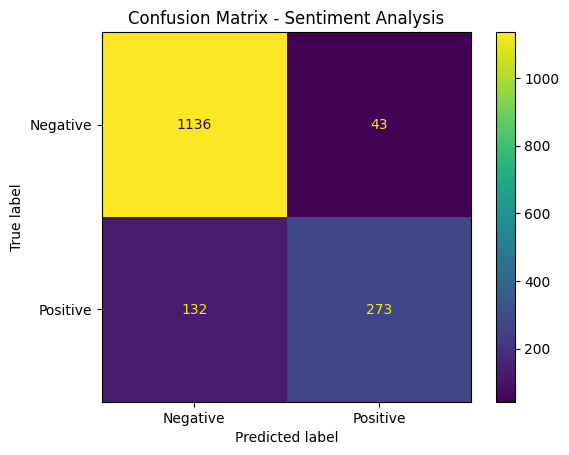

In [36]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Sentiment Analysis"
)

plt.show()

In [37]:
results = pd.DataFrame({
    "Tweet": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Actual Sentiment"] = (
    results["Actual"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

results["Predicted Sentiment"] = (
    results["Predicted"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

display(
    results[
        [
            "Tweet",
            "Actual Sentiment",
            "Predicted Sentiment"
        ]
    ].head(20)
)

,Tweet,Actual Sentiment,Predicted Sentiment
0,what a surprise my phone takes the once again ...,Positive,Positive
1,my new toy love it samsung camera new white ta...,Negative,Negative
2,i have had samsung lg and both i my apple ipho...,Positive,Negative
3,wireless charging water and dust resistant fac...,Negative,Negative
4,coque iphone backface dont fuck with me jokns ...,Positive,Positive
5,lightroom by ig notthreeten new year newyear w...,Negative,Negative
6,blinding light the two little dots at the bott...,Negative,Negative
7,thank you apple always give great customer ser...,Negative,Negative
8,when im free when my sun has set released my s...,Negative,Negative
9,new toy playstation game pes enjoying sony inl...,Negative,Negative


In [38]:
results["Correct"] = (
    results["Actual"]
    ==
    results["Predicted"]
)

print(
    "Prediction Results:"
)

print(
    results["Correct"]
    .value_counts()
)

Prediction Results:
Correct
True     1409
False     175
Name: count, dtype: int64


In [39]:
wrong_predictions = results[
    results["Correct"] == False
]

print(
    "Number of Wrong Predictions:",
    len(wrong_predictions)
)

display(
    wrong_predictions[
        [
            "Tweet",
            "Actual Sentiment",
            "Predicted Sentiment"
        ]
    ].head(20)
)

Number of Wrong Predictions: 175


,Tweet,Actual Sentiment,Predicted Sentiment
2,i have had samsung lg and both i my apple ipho...,Positive,Negative
16,phone shuts down andor restarts itself about t...,Positive,Negative
23,cant even find the stupid fades on final cut p...,Positive,Negative
26,spending £ on a new iphone charger is killing me,Positive,Negative
37,apple has been making the same exact product f...,Negative,Positive
52,gotta love when your macbook charger craps out...,Positive,Negative
53,i realize there may not be overwhelming demand...,Positive,Negative
59,dear apple products why is it so god samn comp...,Negative,Positive
66,loves it when the only button on my iphone sto...,Positive,Negative
71,and i used to do it with my old sony ericsson p,Positive,Negative


In [40]:
wrong_predictions = results[
    results["Correct"] == False
]

print(
    "Number of Wrong Predictions:",
    len(wrong_predictions)
)

display(
    wrong_predictions[
        [
            "Tweet",
            "Actual Sentiment",
            "Predicted Sentiment"
        ]
    ].head(20)
)

Number of Wrong Predictions: 175


,Tweet,Actual Sentiment,Predicted Sentiment
2,i have had samsung lg and both i my apple ipho...,Positive,Negative
16,phone shuts down andor restarts itself about t...,Positive,Negative
23,cant even find the stupid fades on final cut p...,Positive,Negative
26,spending £ on a new iphone charger is killing me,Positive,Negative
37,apple has been making the same exact product f...,Negative,Positive
52,gotta love when your macbook charger craps out...,Positive,Negative
53,i realize there may not be overwhelming demand...,Positive,Negative
59,dear apple products why is it so god samn comp...,Negative,Positive
66,loves it when the only button on my iphone sto...,Positive,Negative
71,and i used to do it with my old sony ericsson p,Positive,Negative


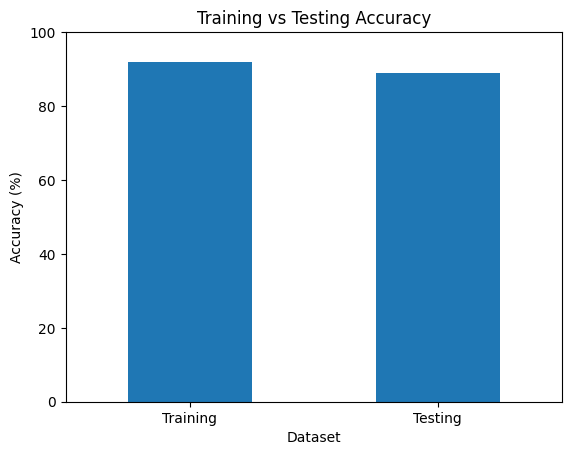

In [41]:
accuracy_data = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],

    "Accuracy": [
        train_accuracy * 100,
        test_accuracy * 100
    ]
})

accuracy_data.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title(
    "Training vs Testing Accuracy"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xlabel(
    "Dataset"
)

plt.xticks(
    rotation=0
)

plt.ylim(
    0,
    100
)

plt.show()

In [43]:
def predict_sentiment(tweet):

    cleaned = clean_tweet(tweet)

    vector = tfidf.transform(
        [cleaned]
    )

    prediction = model.predict(
        vector
    )[0]

    probabilities = model.predict_proba(
        vector
    )[0]

    if prediction == 1:

        sentiment = "Positive"

    else:

        sentiment = "Negative"

    confidence = (
        max(probabilities) * 100
    )

    print(
        "Tweet:",
        tweet
    )

    print(
        "Cleaned Tweet:",
        cleaned
    )

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        "Confidence:",
        round(
            confidence,
            2
        ),
        "%"
    )

    return sentiment

In [44]:
predict_sentiment(
    "I love my new laptop. The performance is excellent and the battery life is amazing."
)

Tweet: I love my new laptop. The performance is excellent and the battery life is amazing.
Cleaned Tweet: i love my new laptop the performance is excellent and the battery life is amazing
Predicted Sentiment: Negative
Confidence: 90.01 %


'Negative'

In [45]:
predict_sentiment(
    "This phone is terrible. The battery drains quickly and the camera quality is very poor."
)

Tweet: This phone is terrible. The battery drains quickly and the camera quality is very poor.
Cleaned Tweet: this phone is terrible the battery drains quickly and the camera quality is very poor
Predicted Sentiment: Negative
Confidence: 52.25 %


'Negative'

In [46]:
new_tweets = [

    "My new laptop is extremely fast and I love it.",

    "This mobile phone is a complete waste of money.",

    "The camera quality of this phone is excellent.",

    "Very disappointed with the customer service.",

    "The new computer works perfectly and I am very happy."
]

for tweet in new_tweets:

    print(
        "\n" + "=" * 70
    )

    predict_sentiment(tweet)


Tweet: My new laptop is extremely fast and I love it.
Cleaned Tweet: my new laptop is extremely fast and i love it
Predicted Sentiment: Negative
Confidence: 91.66 %

Tweet: This mobile phone is a complete waste of money.
Cleaned Tweet: this mobile phone is a complete waste of money
Predicted Sentiment: Negative
Confidence: 58.5 %

Tweet: The camera quality of this phone is excellent.
Cleaned Tweet: the camera quality of this phone is excellent
Predicted Sentiment: Negative
Confidence: 63.25 %

Tweet: Very disappointed with the customer service.
Cleaned Tweet: very disappointed with the customer service
Predicted Sentiment: Negative
Confidence: 61.2 %

Tweet: The new computer works perfectly and I am very happy.
Cleaned Tweet: the new computer works perfectly and i am very happy
Predicted Sentiment: Negative
Confidence: 82.0 %


In [47]:
joblib.dump(
    model,
    "/content/sentiment_analysis_model.pkl"
)

joblib.dump(
    tfidf,
    "/content/tfidf_vectorizer.pkl"
)

print(
    "Model saved successfully."
)

print(
    "TF-IDF Vectorizer saved successfully."
)

Model saved successfully.
TF-IDF Vectorizer saved successfully.


In [48]:
print("=" * 70)

print(
    "SENTIMENT ANALYSIS - FINAL MODEL SUMMARY"
)

print("=" * 70)

print(
    "Problem Type      : Binary Text Classification"
)

print(
    "Input             : Customer Tweets"
)

print(
    "Classes           : Positive and Negative"
)

print(
    "NLP Technique     : TF-IDF"
)

print(
    "Model             : Logistic Regression"
)

print(
    "Train/Test Split  : 80% / 20%"
)

print(
    "Evaluation Metric : Accuracy"
)

print(
    "Training Accuracy :",
    round(
        train_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Testing Accuracy  :",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

print("=" * 70)

SENTIMENT ANALYSIS - FINAL MODEL SUMMARY
Problem Type      : Binary Text Classification
Input             : Customer Tweets
Classes           : Positive and Negative
NLP Technique     : TF-IDF
Model             : Logistic Regression
Train/Test Split  : 80% / 20%
Evaluation Metric : Accuracy
Training Accuracy : 91.89 %
Testing Accuracy  : 88.95 %
